# Wildfire Duration Prediction
**Objective**: Predict how long a fire will burn based on initial discovery conditions.

This notebook demonstrates the end-to-end workflow, using the modular code from the `src` directory.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging

# Configure logging to see output in the notebook
# We use force=True to ensure the logs are displayed even if Jupyter has already configured logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', force=True)

# Add the parent directory to the path so we can import from 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_loader import load_data
from src.features import preprocess_data
from src.train_model import train_model

## 1. Load Data
We load the data from the local SQLite database. We filter for recent years (2010+) to ensure relevance.

In [2]:
# The database is not committed; run scripts/download_data.py first (see README)
db_path = '../data/FPA_FOD_20221014.sqlite'
df = load_data(db_path)
df.head()

2026-01-08 06:25:09,845 - src.data_loader - INFO - Connecting to database at ../data/FPA_FOD_20221014.sqlite...
2026-01-08 06:25:09,847 - src.data_loader - INFO - Executing query...
2026-01-08 06:25:13,224 - src.data_loader - INFO - Successfully loaded 630053 records.


,FIRE_YEAR,DISCOVERY_DATE,DISCOVERY_DOY,CONT_DATE,LATITUDE,LONGITUDE,FIRE_SIZE_CLASS,NWCG_GENERAL_CAUSE
0,2010,8/25/2010,237,8/25/2010,62.332779,-145.358063,A,Power generation/transmission/distribution
1,2010,6/4/2010,155,6/4/2010,61.007221,-149.686951,A,Missing data/not specified/undetermined
2,2010,6/3/2010,154,6/10/2010,62.789166,-141.310837,A,Recreation and ceremony
3,2010,5/7/2010,127,5/16/2010,61.285000,-149.930557,B,Missing data/not specified/undetermined
4,2010,5/7/2010,127,5/21/2010,61.643055,-149.080276,B,Debris and open burning


## 2. Feature Engineering
We transform the raw data into machine-learning-ready features.

**Key Technique: Cyclical Dates**
Instead of using 'Day of Year' (1-365) linearly, we transform it into Sine and Cosine components. This helps the model understand that Day 365 (Dec 31) is temporally close to Day 1 (Jan 1).

In [3]:
X, y = preprocess_data(df)
print("Feature Shape:", X.shape)
X.head()

2026-01-08 06:25:13,326 - src.features - INFO - Starting feature engineering...
2026-01-08 06:25:13,745 - src.features - INFO - Feature engineering complete.
2026-01-08 06:25:13,746 - src.features - INFO - Features (X): (630053, 17), Target (y): (630053,)


Feature Shape: (630053, 17)


,LATITUDE,LONGITUDE,SIN_DOY,COS_DOY,CAUSE_Arson/incendiarism,CAUSE_Debris and open burning,CAUSE_Equipment and vehicle use,CAUSE_Firearms and explosives use,CAUSE_Fireworks,CAUSE_Missing data/not specified/undetermined,CAUSE_Misuse of fire by a minor,CAUSE_Natural,CAUSE_Other causes,CAUSE_Power generation/transmission/distribution,CAUSE_Railroad operations and maintenance,CAUSE_Recreation and ceremony,CAUSE_Smoking
0,62.332779,-145.358063,-0.806480,-0.591261,False,False,False,False,False,False,False,False,False,True,False,False,False
1,61.007221,-149.686951,0.455907,-0.890028,False,False,False,False,False,True,False,False,False,False,False,False,False
2,62.789166,-141.310837,0.471160,-0.882048,False,False,False,False,False,False,False,False,False,False,False,True,False
3,61.285000,-149.930557,0.816538,-0.577292,False,False,False,False,False,True,False,False,False,False,False,False,False
4,61.643055,-149.080276,0.816538,-0.577292,False,True,False,False,False,False,False,False,False,False,False,False,False


## 3. Model Training & Validation
We train a **Random Forest Regressor**.

**Upgrades**:
5-Fold CV

In [6]:
rf_model = train_model(X, y)

2026-01-08 06:27:20,975 - src.train_model - INFO - Splitting data into Train and Test sets (80/20)...
2026-01-08 06:27:21,029 - src.train_model - INFO - Initializing Random Forest Regressor...
2026-01-08 06:27:21,030 - src.train_model - INFO - Performing 5-Fold Cross-Validation (This validates model stability)...
2026-01-08 06:28:46,522 - src.train_model - INFO - Cross-Validation Mean RMSE: 6.3322 (+/- 0.1338)
2026-01-08 06:28:46,523 - src.train_model - INFO - Training final model on full training set...
2026-01-08 06:29:09,471 - src.train_model - INFO - Evaluating on held-out Test Set...
2026-01-08 06:29:09,611 - src.train_model - INFO - ========================================
2026-01-08 06:29:09,612 - src.train_model - INFO - FINAL MODEL PERFORMANCE (TEST SET)
2026-01-08 06:29:09,613 - src.train_model - INFO - RMSE (Root Mean Sq Error): 6.5957 days
2026-01-08 06:29:09,614 - src.train_model - INFO - MAE  (Mean Abs Error):    1.3768 days
2026-01-08 06:29:09,614 - src.train_model - INF

## 4. Evaluation & Visualization
We analyze the model using two key plots:
1. **Feature Importance**: What drives fire duration?
2. **Residual Analysis**: Where is the model making errors?

Feature Importance:


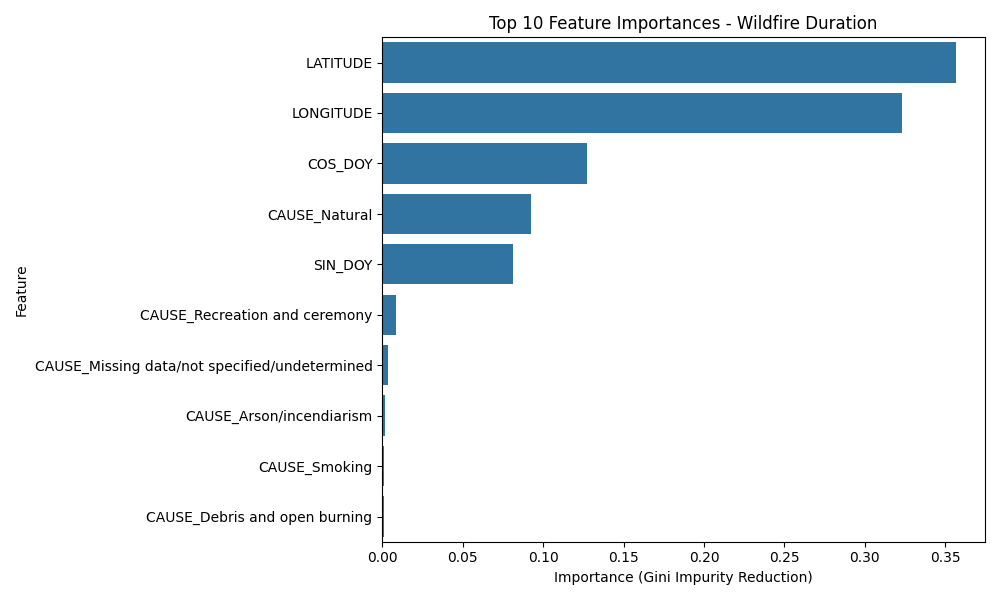

Residual Analysis (Predicted vs Actual):


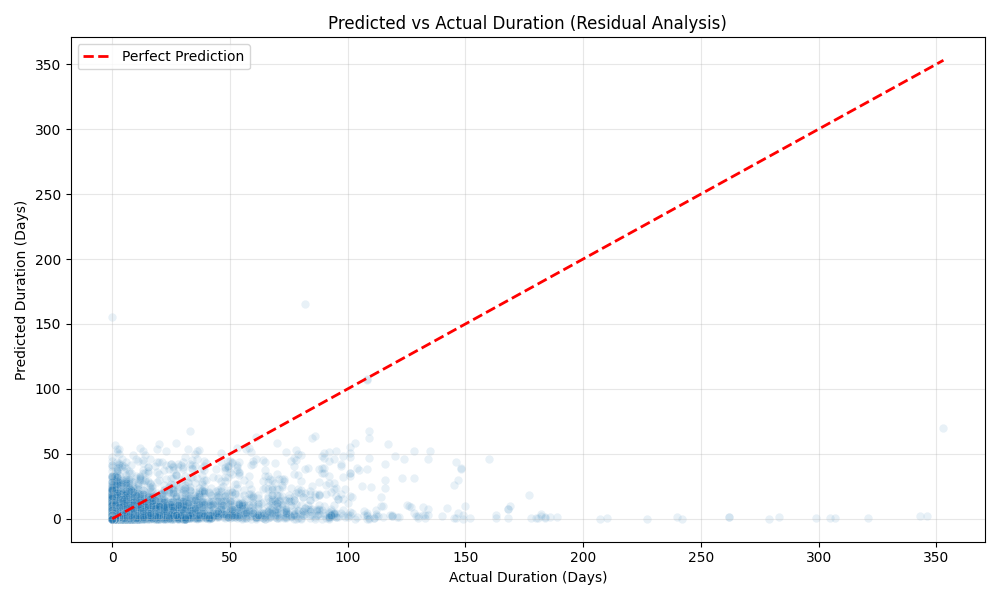

In [5]:
from IPython.display import display, Image

print("Feature Importance:")
display(Image(filename='feature_importance.png'))

print("Residual Analysis (Predicted vs Actual):")
display(Image(filename='residuals.png'))